Title : Multiple linear regression <br>
Author : raghav | Github : @raghavtwenty <br>
Date Created : March 25, 2023 | Last Updated : March 25, 2023 <br>
Python Version : 3.11.2

AIM : <br>
To fit the multiple linear regression and show that minimum correlation exists between the
independent variables using multiple linear analysis. Use Fuel Consumption dataset.

ALGORITHM : <br>
Step 01 : Start the process.<br>
Step 02 : Import the Fuel Consumption dataset.<br>
Step 03 : Check for null values.<br>
Step 04 : Convert the string attributes to int values.<br>
Step 05 : Fit the multiple regression model.<br>
Step 06 : Display the coefficients and plot the pair plot with respect to co2 emissions.<br>
Step 07 : Stop the process.<br>

<br> CODE & OUTPUT<br>

Importing libraries 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

Load the dataset

In [2]:
df = pd.read_csv("/Users/raghav/Documents/Programs/python/ml/datasets/FuelConsumption.csv")

Viewing and description of data

In [3]:
df.head(3)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


Total null values

In [5]:
df.isnull().sum()

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

In [6]:
str_val_col = ['MAKE','MODEL','VEHICLECLASS','TRANSMISSION','FUELTYPE']

Columns with string values <br>
MAKE	MODEL	VEHICLECLASS TRANSMISSION	FUELTYPE 

In [7]:
# Columns having string values
str_val_col = ['MAKE','MODEL','VEHICLECLASS','TRANSMISSION','FUELTYPE']

# List for each string value column
make_uni = sorted(df['MAKE'].unique())

model_uni = sorted(df['MODEL'].unique())

vc_uni = sorted(df['VEHICLECLASS'].unique())

trans_uni = sorted(df['TRANSMISSION'].unique())

ft_uni = sorted(df['FUELTYPE'].unique())

In [8]:
temp_col = ""
temp_uni_col = ""

for item in str_val_col: # Select particular column and temprorary unique sorted column
    print(item)
    match item:
        case 'MAKE':
            temp_col = 'MAKE'
            temp_uni_col = make_uni

        case 'MODEL':
            temp_col = 'MODEL'
            temp_uni_col = model_uni

        case 'VEHICLECLASS':
            temp_col = 'VEHICLECLASS'
            temp_uni_col = vc_uni

        case 'TRANSMISSION':
            temp_col = 'TRANSMISSION'
            temp_uni_col = trans_uni

        case 'FUELTYPE':
            temp_col = 'FUELTYPE'
            temp_uni_col = ft_uni


    for col_val in df[temp_col]:    # Select value in the current column
        for uni_val in temp_uni_col:     # Select value in the corresponding unique sorted column list
            if (col_val == uni_val):  
                df[temp_col] = df[temp_col].replace([col_val],int(temp_uni_col.index(uni_val)))

MAKE
MODEL
VEHICLECLASS
TRANSMISSION
FUELTYPE


All the string valued columns values had been changed to integers 😀

In [9]:
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,0,329,0,2.0,4,10,3,9.9,6.7,8.5,33,196
1,2014,0,329,0,2.4,4,20,3,11.2,7.7,9.6,29,221
2,2014,0,330,0,1.5,4,17,3,6.0,5.8,5.9,48,136
3,2014,0,389,11,3.5,6,11,3,12.7,9.1,11.1,25,255
4,2014,0,483,11,3.5,6,11,3,12.1,8.7,10.6,27,244


In [10]:
df.corr()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MAKE,NaN,1.000000,0.039068,0.005853,-0.166416,-0.203427,0.193264,0.015051,-0.246247,-0.174665,-0.222273,0.226347,-0.186504
MODEL,NaN,0.039068,1.000000,0.244648,0.096304,0.080010,-0.002004,-0.051902,0.147394,0.182009,0.161373,-0.148806,0.155492
VEHICLECLASS,NaN,0.005853,0.244648,1.000000,0.240529,0.208528,-0.172934,-0.083893,0.354363,0.430074,0.384678,-0.354073,0.388468
ENGINESIZE,NaN,-0.166416,0.096304,0.240529,1.000000,0.934011,-0.272427,0.060869,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,NaN,-0.203427,0.080010,0.208528,0.934011,1.000000,-0.246456,0.127959,0.796473,0.724594,0.776788,-0.770430,0.849685
TRANSMISSION,NaN,0.193264,-0.002004,-0.172934,-0.272427,-0.246456,1.000000,0.214650,-0.350241,-0.348174,-0.352596,0.341119,-0.299393
FUELTYPE,NaN,0.015051,-0.051902,-0.083893,0.060869,0.127959,0.214650,1.000000,-0.128841,-0.178439,-0.148167,0.007106,0.075167
FUELCONSUMPTION_CITY,NaN,-0.246247,0.147394,0.354363,0.832225,0.796473,-0.350241,-0.128841,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,NaN,-0.174665,0.182009,0.430074,0.778746,0.724594,-0.348174,-0.178439,0.965718,1.000000,0.985804,-0.893809,0.861748


Create the Regression model

In [11]:
model = LinearRegression()
new_x = ['MAKE','MODEL','VEHICLECLASS','ENGINESIZE','CYLINDERS','TRANSMISSION','FUELTYPE',
    'FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',
    'FUELCONSUMPTION_COMB_MPG']
new_y = 'CO2EMISSIONS'
model.fit(df[new_x],df[new_y])

LinearRegression()

Viewing the scores

In [12]:
coef = model.coef_ #m
intercept = model.intercept_ #c

print(f'''
Coefficient : {coef}
Intercept : {intercept} 
Equation : {coef[:].sum()} * x + {intercept}''')

new_score = model.score(df[new_x],df[new_y])

print(f"\nSCORE OF THE MODEL WITH ALL THE ATTRIBUTES : {new_score:.2f}")


Coefficient : [ 8.10332944e-02  4.05174629e-03  1.09781294e+00  9.25032927e+00
  5.78855011e+00 -9.54347524e-03  7.79620789e+00 -1.07647844e+01
 -8.77501870e+00  2.39925707e+01 -3.02313408e+00]
Intercept : 192.78753511437696 
Equation : 25.43807530167502 * x + 192.78753511437696

SCORE OF THE MODEL WITH ALL THE ATTRIBUTES : 0.90


Checking without string converted columns

In [13]:
old_model = LinearRegression()
old_x = ['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY',
    'FUELCONSUMPTION_COMB','FUELCONSUMPTION_COMB_MPG']
old_y = 'CO2EMISSIONS'
old_model.fit(df[old_x],df[old_y])

coef = old_model.coef_ #m
intercept = old_model.intercept_ #c

print(f'''
Coefficient : {coef}
Intercept : {intercept} 
Equation : {coef[:].sum()} * x + {intercept}''')

old_score = old_model.score(df[old_x],df[old_y])
print(f"\nSCORE OF THE MODEL WITH  INT ATTRIBUTES ONLY : {old_score:.2f}")


Coefficient : [  8.57767262   7.698747   -10.59262337  -3.48918281  17.75286099
  -3.86924281]
Intercept : 253.53120114591718 
Equation : 16.078231605906943 * x + 253.53120114591718

SCORE OF THE MODEL WITH  INT ATTRIBUTES ONLY : 0.89


Score difference 

In [14]:
print(f"SCORE DIFFERENCE : {new_score-old_score}")

SCORE DIFFERENCE : 0.012562057515417835


Viewing the prediction line

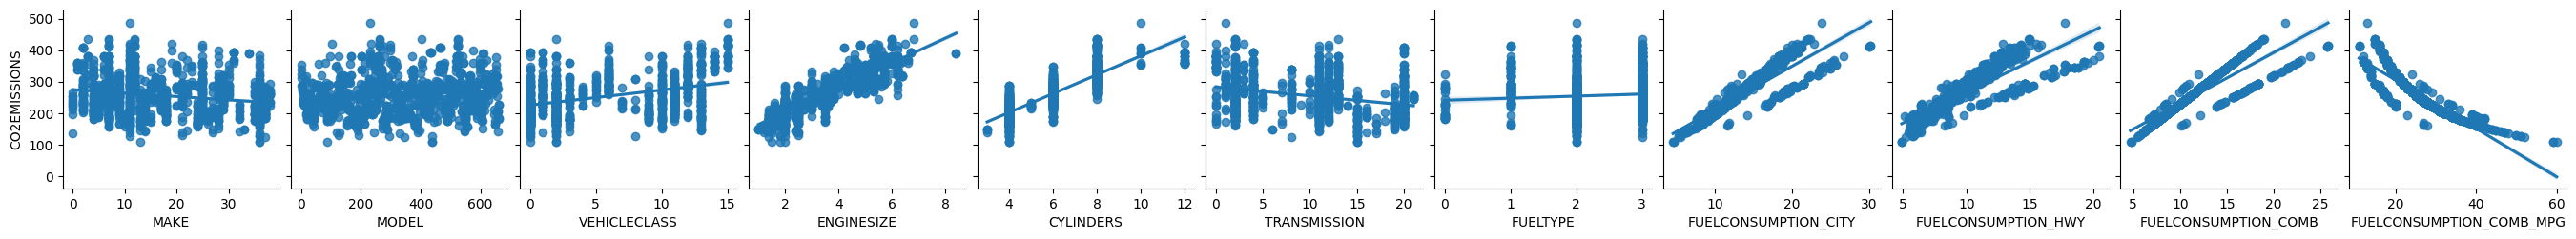

In [15]:
sns.pairplot(df, x_vars = new_x, y_vars = new_y, kind= 'reg')

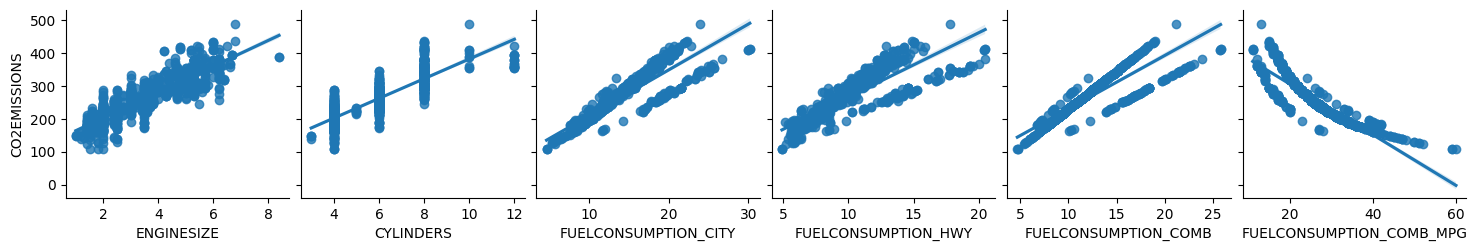

In [16]:
sns.pairplot(df, x_vars = old_x, y_vars = old_y, kind= 'reg')

<Axes: >

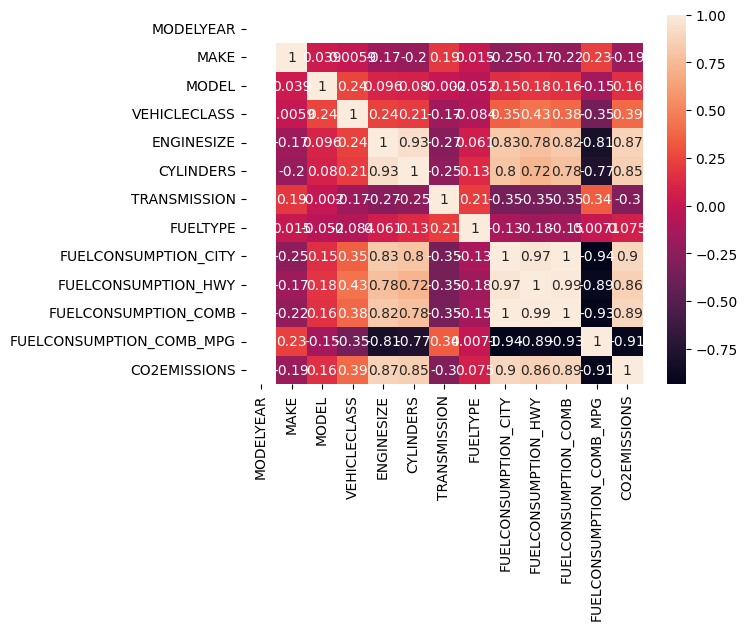

In [17]:
sns.heatmap(df.corr(), annot=True)

<Axes: >

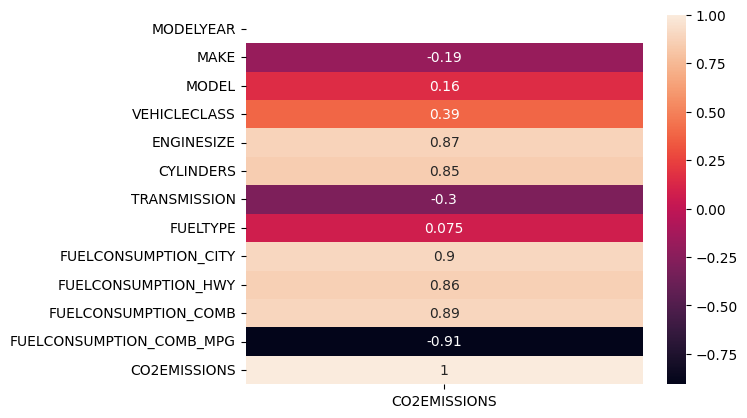

In [18]:
sns.heatmap(df.corr() [[new_y]],annot=True)

INFERENCE

As the ENGINESIZE increases the CO2 EMISSIONS increase by 0.87%  <br>
As the FUELCONSUMPTION in the city increases the CO2 EMISSIONS increase by 0.90% <br>
As the FUELCONSUMPTION in the highway increases the CO2 EMISSIONS increase by 0.89% <br>

The fuel consumption in city is the highest correleated attribute <br>
The fuel consumption combination of miles per gallon is the lowest correlated attibute <br>